# Assignment 3: Vision Transformers

Welcome to the third assignment! We're excited to see what you'll create using the techniques you've learned in this course.

First of all, please type your name and UID in the following format:

Firstname Lastname, #UID

In this assignment we will write a Vision Transformer, and use it for classification on Miniplaces, and semantic segmentation on ADE20K

In [ ]:
#@title Your Info { display-mode: "form" }

Name = 'Na Yoon Kang' #@param {type:"string"}
UID = '405345189' #@param {type:"string"}

## Goals
The goals of this assignment are to:

1. Build a Vision Transformer (ViT) from scratch .
2. Build a Semantic Segmentation model using a ViT encoder

By the end of this assignment, you will have gained experience with:

- Working with PyTorch and the MiniPlaces dataset for image classification.
- Working with PyTorch and the ADE20K dataset for semantic segmentation.
- Debugging and troubleshooting issues that may arise during the development process.

Please note that it may take some time to run the entire notebook and prepare the submission version. Make sure to allocate enough time for this task and start early. If you have any questions or run into any issues, please feel free to raise them in the Piazza forum or search the internet for debugging purposes. However, please do not directly copy code from other sources.

This assignment is due on ***Sunday, Nov 23***.

**Do not use any Code AI to finish the assignment.**


Good luck and happy coding! Remember, the most important thing is to have fun and learn something new.




## Setup Code


To begin, you will need to download the MiniPlaces Dataset (`MiniPlaces.zip`) from UCLA box

-----


Recall the introduction about the storage system of Colab we went through in the assignment 1. For efficient development of our models, we will still use the temporary storage space to hold our data. This means that every time you open up this notebook, we will need to re-upload and process the dataset. Don't worry though - this shouldn't take long, usually just a minute or less. Okay, let's get started!

We will additionally install the [einops](https://einops.rocks/) package, which is a handy tool designed to simplify and make more readable tensor operations in deep learning and scientific computing:

In [ ]:
!pip install einops

In [ ]:
# Import all the common packages, you can just rerun this cell if you restart the kernel and found some packages are missing
# It is also good for you to get familiar with these packages
import cv2 # defines functions for computer vision tasks
import matplotlib.pyplot as plt # defines functions for plotting
import numpy as np # defines functions for manipulating arrays
import os # defines operating system related functions
import random # defines functions for generating random numbers
import torch # defines functions for tensor computations
import torch.nn as nn # defines modules for building neural networks
import torch.nn.functional as F # defines functions for building neural networks
from PIL import Image  # defines the Python Imaging Library (Pillow) for image processing
from torchvision import transforms # defines functions for image transformations
from torch.utils.data import DataLoader, Dataset # defines functions for data loading and dataset handling
from tqdm import tqdm # defines functions for displaying progress bars
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

In [ ]:
# Let's make our assignment directory
CS163_path = './CS163'
os.makedirs(CS163_path, exist_ok=True)
# os.makedirs will create directories recursively, i.e., it will create the
# directories and any missing parent directories if they do not exist.

# Now, let's specify the assignment path we will be working with as the root.
root_dir = os.path.join(CS163_path, 'MiniPlaces')

!wget -O MiniPlaces.zip https://ucla.box.com/shared/static/ikd1jsad17no71bugzhw3nkrhkdq12x0.zip
!unzip -q MiniPlaces.zip -d ./CS163

--2025-11-21 23:51:36--  https://ucla.box.com/shared/static/ikd1jsad17no71bugzhw3nkrhkdq12x0.zip
Resolving ucla.box.com (ucla.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to ucla.box.com (ucla.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/ikd1jsad17no71bugzhw3nkrhkdq12x0.zip [following]
--2025-11-21 23:51:36--  https://ucla.box.com/public/static/ikd1jsad17no71bugzhw3nkrhkdq12x0.zip
Reusing existing connection to ucla.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://ucla.app.box.com/public/static/ikd1jsad17no71bugzhw3nkrhkdq12x0.zip [following]
--2025-11-21 23:51:36--  https://ucla.app.box.com/public/static/ikd1jsad17no71bugzhw3nkrhkdq12x0.zip
Resolving ucla.app.box.com (ucla.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to ucla.app.box.com (ucla.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response..

### Define the data transform


In [ ]:
image_net_mean = torch.Tensor([0.485, 0.456, 0.406])
image_net_std = torch.Tensor([0.229, 0.224, 0.225])

# Notice we are resize images to 128x128 instead of 64x64.
data_transform = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(image_net_mean, image_net_std),
])


### Define the dataset and dataloader

In [ ]:
# You can copy your dataset from Assignment2.
class MiniPlaces(Dataset):
    def __init__(self, root_dir, split, transform=None, label_dict=None):
        """
        Initialize the MiniPlaces dataset with the root directory for the images,
        the split (train/val/test), an optional data transformation,
        and an optional label dictionary.

        Args:
            root_dir (str): Root directory for the MiniPlaces images.
            split (str): Split to use ('train', 'val', or 'test').
            transform (callable, optional): Optional data transformation to apply to the images.
            label_dict (dict, optional): Optional dictionary mapping integer labels to class names.
        """
        assert split in ['train', 'val', 'test']
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.filenames = []
        self.labels = []

        self.label_dict = label_dict if label_dict is not None else {}

        with open(f'{root_dir}/{split}.txt', 'r') as f:
            lines = f.readlines()

        for line in lines:
            image_path, label = line.split(' ')
            label = int(label)
            self.filenames.append(image_path)
            self.labels.append(label)
            if split == 'train':
                self.label_dict[label] = image_path.split('/')[-2]

    def __len__(self):
        """
        Return the number of images in the dataset.

        Returns:
            int: Number of images in the dataset.
        """
        return len(self.filenames)

    def __getitem__(self, idx):
        """
        Return a single image and its corresponding label when given an index.

        Args:
            idx (int): Index of the image to retrieve.

        Returns:
            tuple: Tuple containing the image and its label.
        """
        label = self.labels[idx]
        image_path = self.filenames[idx]
        image = Image.open(os.path.join(self.root_dir, f'images/{image_path}'))
        image = self.transform(image)

        return image, label

### Define the train method

In [ ]:
def train(model, train_loader, val_loader, optimizer, criterion, device, num_epochs):
    """
    Train the MLP classifier on the training set and evaluate it on the validation set every epoch.

    Args:
        model (MLP): MLP classifier to train.
        train_loader (torch.utils.data.DataLoader): Data loader for the training set.
        val_loader (torch.utils.data.DataLoader): Data loader for the validation set.
        optimizer (torch.optim.Optimizer): Optimizer to use for training.
        criterion (callable): Loss function to use for training.
        device (torch.device): Device to use for training.
        num_epochs (int): Number of epochs to train the model.
    """
    # Place model on device
    model = model.to(device)

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        # Use tqdm to display a progress bar during training
        with tqdm(total=len(train_loader), desc=f'Epoch {epoch + 1}/{num_epochs}') as pbar:
            for inputs, labels in train_loader:
                # Move inputs and labels to device
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero out gradients
                optimizer.zero_grad()

                # Compute the logits and loss
                logits = model(inputs)
                loss = criterion(logits, labels)

                # Backpropagate the loss
                loss.backward()

                # Update the weights
                optimizer.step()

                # Update the progress bar
                pbar.update(1)
                pbar.set_postfix(loss=loss.item())

        # Evaluate the model on the validation set
        avg_loss, accuracy = evaluate(model, val_loader, criterion, device)
        print(f'Validation set: Average loss = {avg_loss:.4f}, Accuracy = {accuracy:.4f}')

def evaluate(model, test_loader, criterion, device):
    """
    Evaluate the MLP classifier on the test set.

    Args:
        model (MLP): MLP classifier to evaluate.
        test_loader (torch.utils.data.DataLoader): Data loader for the test set.
        criterion (callable): Loss function to use for evaluation.
        device (torch.device): Device to use for evaluation.

    Returns:
        float: Average loss on the test set.
        float: Accuracy on the test set.
    """
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():
        total_loss = 0.0
        num_correct = 0
        num_samples = 0

        for inputs, labels in test_loader:
            # Move inputs and labels to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Compute the logits and loss
            logits = model(inputs)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            # Compute the accuracy
            _, predictions = torch.max(logits, dim=1)
            num_correct += (predictions == labels).sum().item()
            num_samples += len(inputs)

    # Compute the average loss and accuracy
    avg_loss = total_loss / len(test_loader)
    accuracy = num_correct / num_samples

    return avg_loss, accuracy

In [ ]:
def compute_distances_no_loops(x_train, x_test):
  num_train = x_train.shape[0]
  num_test = x_test.shape[0]
  dists = x_train.new_zeros(num_train, num_test)

  A = x_train.reshape(num_train,-1)
  B = x_test.reshape(num_test,-1)
  AB2 = A.mm(B.T)*2
  dists = ((A**2).sum(dim = 1).reshape(-1,1) - AB2 + (B**2).sum(dim = 1).reshape(1,-1))**(1/2)
  return dists

def predict_labels(dists, y_train, k=1):
  num_train, num_test = dists.shape
  y_pred = torch.zeros(num_test, dtype=torch.int64)

  values, indices = torch.topk(dists, k, dim=0, largest=False)
  for i in range(indices.shape[1]):
    _, idx = torch.max(y_train[indices[:,i]].bincount(), dim = 0)
    y_pred[i] = idx
  return indices, y_pred

class KnnClassifier:
  def __init__(self, x_train, y_train):
    self.x_train = x_train
    self.y_train = y_train

  def predict(self, x_test, k=1):
    y_test_pred = None

    dists = compute_distances_no_loops(self.x_train, x_test)
    _, y_test_pred =  predict_labels(dists, self.y_train, k)

    return y_test_pred

  def check_accuracy(self, x_test, y_test, k=1, quiet=False):
    y_test_pred = self.predict(x_test, k=k)
    num_samples = x_test.shape[0]
    num_correct = (y_test == y_test_pred).sum().item()
    accuracy = 100.0 * num_correct / num_samples
    msg = (f'Got {num_correct} / {num_samples} correct; '
           f'accuracy is {accuracy:.2f}%')
    if not quiet:
      print(msg)
    return accuracy

In [ ]:
# Also, seed everything for reproducibility
# code from https://gist.github.com/ihoromi4/b681a9088f348942b01711f251e5f964#file-seed_everything-py
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

In [ ]:
# Define the device to use for training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device == torch.device('cuda'):
    print(f'Using device: {device}. Good to go!')
else:
    print('Please set GPU via Edit -> Notebook Settings.')

Using device: cuda. Good to go!


In [ ]:
! nvidia-smi

Fri Nov 21 23:53:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             46W /  400W |       5MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Q1: Steps to build a ViT from scratch (60 pts)
Vision Transformer (ViT) is a state-of-the-art neural network architecture for image classification tasks. Unlike traditional convolutional neural networks (CNNs), which have been the standard in computer vision for many years, ViT relies on a self-attention mechanism to extract features from images. This approach has shown to achieve competitive results on various benchmark datasets, while also offering the flexibility to handle tasks that require attention over long-range dependencies in images. ViT has quickly gained popularity in the computer vision community, and has spurred further research into the use of self-attention mechanisms in other areas of deep learning.

You will implement the ViT model on the Miniplaces dataset.

To implement ViT model for image classification, you will need to follow these steps：
1.  Extract feature vectors from the input images using a trainable linear projection layer, which converts the 2D image patches into 1D feature vectors.
2. Positional encoding: Add a learnable positional encoding to each feature vector, which provides spatial information to the model.
3. Transformer encoder: Stack multiple Transformer encoder layers to process the encoded features, which allows the model to learn both local and global interactions between the image patches.
4. Classification head: Add a classification head on top of the final encoded feature vector, which maps the learned representations to the corresponding class labels.
5. Training and evaluation: Train the ViT model using an appropriate optimization algorithm and loss function, and evaluate its performance on the validation and testing sets.

If you are not familiair with ViT model, then you can read our textbook [Transformers for Vision](https://d2l.ai/chapter_attention-mechanisms-and-transformers/vision-transformer.html#fig-vit), or review our [discussion slides](https://drive.google.com/file/d/1RKSnE9MOAGBu9T-_2TaBEm4ASF189Fms/view).

### Q1.1: Tokenization (10 pts):
At this step, we need to divide each image into a set of non-overlapping patches, and treat each patch as a token. This is the key step that distinguishes ViT from other computer vision models.

#### Q1.1.1 Tokenize_image Method (5pts)

In [ ]:
def tokenize_image(img, patch_size=16, stride=16):
    """
    Tokenize an image into non-overlapping image patches.
    Args:
        img (torch.Tensor): The input image with shape (C, H, W).
        patch_size (int): The size of each patch.
        stride (int): The stride of the sliding window.
    Returns:
        patches (torch.Tensor): The tokenized patches with shape (N, patch_size*patch_size*C).
    """

    C, H, W = img.shape
    patches = []
    ################# Your Implementations #################################
    # Hints: write two for loop to loop over this image
    # Each patch is flattened into a 1-dimensional vector and stacked into a
    # tensor with shape (N, patch_size(H) * patch_size(W) * C), where N is the number of patches.
    # We only consider the case image size can be modulo by the patch_size

    # Additionally, before flattening, remember to permute the patch such that
    # it has shape (patch_size(H), patch_size(W), C)
    for i in range(0, H, stride):
      for j in range(0, W, stride):
        # shape is (C, patch_size, patch_size)
        patch = img[:, i:i+patch_size, j:j+patch_size]
        # permute to (patch_size, patch_size, C)
        patch = patch.permute(1,2,0)

        patch_flat = patch.flatten()
        patches.append(patch_flat)

    patches = torch.stack(patches)


    ################# End of your Implementations ##########################
    return patches

In [ ]:
# test your implementation of tokenize_image
random_img = torch.rand(3,64,64)
patched_img = tokenize_image(random_img,8,8)

for i in [32,16,8,4,2]:
    out = tokenize_image(random_img,i,i)

    fast_patch = Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = i, p2 = i)

    answer = fast_patch(random_img.unsqueeze(0))
    equal = torch.allclose(out,answer.squeeze(0))
    #print('Difference: ', equal)
    if equal:
      print('Good! For patch_size: %d, the output match' %(i))
    else:
      print('Uh-oh! For patch_size: %d, the output are different' %(i))
      break

Good! For patch_size: 32, the output match
Good! For patch_size: 16, the output match
Good! For patch_size: 8, the output match
Good! For patch_size: 4, the output match
Good! For patch_size: 2, the output match


#### Q1.1.2 linear projection layer (5 pts)

At this step, you will need to implement the linear projection linear project layer combined with tokenize operation.

This layer is used to transfer a single image to the image embedding.

In [ ]:
class Tokenization_layer(nn.Module):
  def __init__(self, dim, patch_dim,patch_height, patch_width):
    super().__init__()
    """
        Args:
          dim (int): input and output dimension.
          patch_dim(int): falttened vectot dimension for image patch
          patch_height (int): height of one image patch
          patch_weight (int): weight of one image patch

        You can use Pytorch's built-in function and the above Rearrange method.
        Input and output shapes of each layer:
        1) Rerrange the image: (batch_size, channels, H,W) -> (batch_size,N,patch_dim)
        2) Norm Layer1 (LayerNorm): (batch_size,N,patch_dim) -> (batch_size,N,patch_dim)
        3) Linear Projection layer: (batch_size,N,patch_dim) -> (batch_size,N,dim)
        4) Norm Layer2 (LayerNorm): (batch_size,N,dim)-> (batch_size,N,dim)
    """

    self.to_patch = Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width)
    self.norm1 = None
    self.fc1 = None
    self.norm2 = None

    ################# Your Implementations #################################
    # Hints: You can use the Rearrange method above to achieve faster patch operation
    # Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width)

    self.norm1 = nn.LayerNorm(patch_dim)
    self.fc1 = nn.Linear(patch_dim, dim)
    self.norm2 = nn.LayerNorm(dim)

    ################# End of your Implementations ##########################

  def forward(self, x):
    """
    Args:
      x (torch.Tensor): input tensor in the shape of (batch_size,C,H,W)
    Return:
      out (torch.Tensor): output patch embedding tensor in the shape of (batch_size,N,dim)

     The input tensor 'x' should pass through the following layers:
     1) self.to_patch: Rerrange image
     2) self.norm1: LayerNorm
     3) self.fc1: Fully-Connected layer
     4) self.norm2: LayerNorm

    """

    out = None
    ################# Your Implementations #################################


    out = self.to_patch(x)
    out = self.norm1(out)
    out = self.fc1(out)
    out = self.norm2(out)


    ################# End of your Implementations ##########################
    return out


### Q1.2 Attention (15 pts):
You will need to follow the steps to implement multi-head attention in this question.
1. **Obtain Q,K,V vectors**: To obtain the Q, K, and V vectors, the input vectors are processed through three distinct single linear layers. In our implementation, we use a single linear layer with 3xD output channels, and then we divide the output into three chunks. We consider the first chunk as the Q vectors, the second chunk as the K vectors, and the last chunk as the V vectors.

2. **Calculate similarity**: Compute the similarity scores between query vectors and a set of key vectors using a dot product.

3. **Apply softmax**: Apply a softmax function to normalize the similarity scores across the key vectors. This creates a probability distribution that represents the relative importance of each key vector with respect to the query vector.

4. **Compute weighted sum**: Compute a weighted sum of the** value vectors**, where the weights are the probability distribution obtained in step 2. This produces a context vector that summarizes the most relevant information from the value vectors with respect to the query vector.

5. **Concatenate output**: The outputs of each head are then concatenated and passed through another linear projection to produce the final output.

For more details, you can read our [textbook](https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html).

In [ ]:
class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        """
        Args:
          dim (int): input and output dimension.
          heads (int): number of attention heads.
          dim_head (int): input dimension of each attention head.
          dropout (float): dropout rate for attention and final_linear layer.

        Initialize a attention block.
        You can use Pytorch's built-in function.
        Input and output shapes of each layer:
        1) Define the inner dimension as number of heads* dimension of each head
        2) to_qkv: (batch_size, dim) -> (batch_size,3*inner_dimension)
        3) final_linear: (batch_size, inner_dim) -> (batch_size, dim)
        """

        self.heads = heads
        self.dim_head = dim_head

        self.inner_dim = dim_head *  heads


        self.attend = None
        self.dropout = None
        self.final_linear = None


        # Here, you should define
        # 1) self.to_qkv: (batch_size, dim) -> (batch_size,3*inner_dimension)
        # 2) self.dropout: Dropout layer with ratio defined by dropout variable
        # 3) self.final_linear: (batch_size, inner_dim) -> (batch_size, dim)
        ################# Your Implementations #################################

        self.to_qkv = nn.Linear(dim, 3*self.inner_dim, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.final_linear = nn.Linear(self.inner_dim, dim)

        ################# End of your Implementations ##########################

    def forward(self, x):
        '''
        Forward pass of the attention block.
        Args:
            x (torch.Tensor): input tensor in the shape of (batch_size,N,dim).
        Returns:
            out (torch.Tensor): output tensor in the shape of (batch_size,N,dim).

        The input tensor 'x' should pass through the following layers:
        1) to_qkv: (batch_size,N,dim) -> (batch_size,N,3*inner_dimension)
        2) Divide the ouput of to qkv to q,k,v and then divide them in to n heads
            (batch_size,N,inner_dim) -> (batch_size,N,num_head,head_dim)
        3) Use torch.matmul to get the product of q and k
        4) Divide the above tensor by the squre root of head dimension
        5) Apply softmax and then dropout on the above tensor
        6) Mutiply the above tensor with v to get attention
        7) Concatenate the attentions from multi-heads
            (batch_size,N,num_head,head_dim) -> (batch_size,N,inner_dim)
        8) Pass the output from last step to a fully connected layer
        9) Apply dropout for the last step output
        '''
        out = None

        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)
        ################# Your Implementations #################################
        # Hint you can use :
        #    out = rearrange(out, 'b h n d -> b n (h d)')
        # to concatenate the output from all attention heads
        # This operation will change the tensor shape from (batch_size,N,num_head,head_dim)
        # to  (batch_size,N,inner_dim)

        # do i have to transpose k to do q*k^T? (Ask in discussion)
        qk_dot = torch.matmul(q, k.transpose(-1,-2))

        qk_dot = qk_dot / (self.dim_head**0.5)

        attn = qk_dot.softmax(dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)

        out = rearrange(out, 'b h n d -> b n (h d)')

        out = self.final_linear(out)

        out = self.dropout(out)

        ################# End of your Implementations ##########################
        return out

In [ ]:
# You can use this cell to check if the output shape of attention'
for dim in [512,768,1096]:
  test_tensor = torch.rand(2,196,dim)
  att_layer = Attention(dim,8,64,0.4)
  output_tensor = att_layer(test_tensor)
  equal =  test_tensor.shape == output_tensor.shape
  if equal:
    print('Good! For input dim: %d, the output shape is correct' %(dim))
  else:
    print('Uh-oh! For input dim: %d, the output shape is wrong' %(dim))
    break

Good! For input dim: 512, the output shape is correct
Good! For input dim: 768, the output shape is correct
Good! For input dim: 1096, the output shape is correct


The norm layer in Vision Transformer (ViT) is a layer that performs layer normalization on the input. It is typically applied after the Multi-Head Attention (MHA) and the MLP layers in the ViT architecture. The norm layer is used to help the model learn better representations by ensuring that the activations are normalized and centered.

In [ ]:
### PreNorm function
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn
    def forward(self, x, **kwargs):
        # keey the residual connection here
        return self.fn(self.norm(x), **kwargs)+x

In [ ]:
#You can use
a = PreNorm(768, Attention(768, heads = 8, dim_head = 64, dropout = 0.2))
# to create a combination of layer norm and any other layer
test_tensor = torch.rand(2,196,768)
# you can use the following line to do the forward pass
output_tensor = a(test_tensor)

### Q1.3 PositionwiseFeedForward(5 pt)
You will need to implement the posiotionwiseFeedForward layer in Vision Transformer.

The FFN layer is called "position-wise" because it applies a separate feedforward network to each position in the sequence independently. It consists of two linear transformations with a non-linear activation function in between, typically GELU. The first linear transformation maps the input feature vector from its original dimension to a higher-dimensional space, and the second linear transformation maps it back to the original dimension. The output of the FFN layer is the element-wise sum of the input and the transformed feature vector.

In [ ]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."
    def __init__(self, dim, mlp_dim, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        """
         Args:
          dim (int): input and output dimension.
          mlp_dim (int): the output dimension of the first layer.
          dropout (float): dropout rate for both linear layers.

        Initialize an MLP.
        You can use Pytorch's built-in nn.Linear function.
        Input and output sizes of each layer:
          1) fc1: dim, mlp_dim
          2) fc2: mlp_dim, dim
        """

        self.fc1 = None
        self.fc2 = None
        self.dropout = None
        self.activation = nn.GELU()
        ################# Your Implementations #################################

        self.fc1 = nn.Linear(dim, mlp_dim)
        self.fc2 = nn.Linear(mlp_dim, dim)
        self.dropout = nn.Dropout(dropout)

        ################# End of your Implementations ##########################

    def forward(self, x):
        '''
        Args:
            x (torch.Tensor): input tensor in the shape of (batch_size,N,dim).
        Returns:
            out (torch.Tensor): output tensor in the shape of (batch_size,N,dim).

        The input tensor 'x' should pass through the following layers:
        1) fc1: (batch_size,N,dim) ->  (batch_size,N,mlp_dim)
        2) Apply activation function
        3) Apply dropout
        3) fc2: (batch_size,N,mlp_dim) -> (batch_size,N,dim)
        4) Apply dropout
        '''

        out = None
        ################# Your Implementations #################################

        out = self.fc1(x)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.dropout(out)

        ################# End of your Implementations ##########################
        return out

In [ ]:
# You can use this cell to check if the output shape of PositionwiseFeedForward
for dim in [512,768,1096]:
  test_tensor = torch.rand(2,196,dim)
  ffn = PositionwiseFeedForward(dim,dim*4,0.1)
  output_tensor = ffn(test_tensor)
  equal =  test_tensor.shape == output_tensor.shape
  if equal:
    print('Good! For input dim: %d, the output shape is correct' %(dim))
  else:
    print('Uh-oh! For input dim: %d, the output shape is wrong' %(dim))
    break

Good! For input dim: 512, the output shape is correct
Good! For input dim: 768, the output shape is correct
Good! For input dim: 1096, the output shape is correct


### Q1.4 TransformerBlock (5pt)
Now you can follow the steps and use above class to implement the standard transformer block as demostrated in the following image.

 <img src="https://web.cs.ucla.edu/~smo3/cs188/assignment3/transformer_block.png"  width="20%" height="40%">

1. Apply Layer-norm to the input tensor
2. Apply the Multi-Head Attention (MHA) layer to the output tensor from step1. The MHA layer takes in the input tensor, and returns the attention scores and the attention output tensor.
3. Add the residual connection to the output of the MHA layer.
4. Apply Layer-norm to output of last step
5. Apply the Position-wise Feedforward Network (FFN) layer to the output of the previous step. The FFN layer takes in the output tensor, and returns the transformed output tensor.
6. Add the residual connection to the output of the FFN layer.

In [ ]:
class Transformer(nn.Module):
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout = 0.):
        "Implements Transformer block."
        super().__init__()
        '''
        Args:
          dim (int): input and output dimension.
          heads (int): number of attention heads.
          dim_head (int): input dimension of each attention head.
          mlp_dim (int):
          dropout (float): dropout rate for attention and FFN layers.

        '''
        # Use the PreNorm,Attention and PositionwiseFeedForword class to build your
        # Transformer block
        self.attn = None
        self.ff = None

        ################# Your Implementations #################################

        self.attn = PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout))
        self.ff = PreNorm(dim, PositionwiseFeedForward(dim, mlp_dim, dropout=dropout))

        ################# End of your Implementations ##########################

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): input tensor in the shape of (batch_size,N,dim).
        Returns:
            out (torch.Tensor): output tensor in the shape of (batch_size,N,dim).
        """
        ################# Your Implementations #################################

        out = None
        out = self.attn(x)
        out = self.ff(out)

        ################# End of your Implementations ##########################
        return out

In [ ]:
# You can use this cell to check if the output shape of Transformer
for dim in [512,768,1096]:
  test_tensor = torch.rand(2,196,dim)
  transformer_block = Transformer(dim,8,64,dim*4,0.1)
  output_tensor = transformer_block(test_tensor)
  equal =  test_tensor.shape == output_tensor.shape
  if equal:
    print('Good! For input dim: %d, the output shape is correct' %(dim))
  else:
    print('Uh-oh! For input dim: %d, the output shape is wrong' %(dim))
    break

Good! For input dim: 512, the output shape is correct
Good! For input dim: 768, the output shape is correct
Good! For input dim: 1096, the output shape is correct


### Q1.5 ViTModel (20 pts)
Now you can use above classes to build your Vision Transfromer. Recall the ViT Architecture.

 <img src="https://web.cs.ucla.edu/~smo3/cs188/assignment3/vit.png"  width="40%" height="40%">

 Recall the pipline for Vision Transformer model:

1. Load the input images and preprocess them into a set of image patches. The patches should be non-overlapping and should cover the entire input image. Each patch should be flattened into a vector and projected into a lower-dimensional/equal-dimensional space using a linear layer.

2. Add cls token and learnable positional embeddings to the projected patch vectors. The positional embedding should encode the spatial location of each patch in the input image.

3. Stack several Transformer blocks to process the patch vectors. Each Transformer block should consist of a Multi-Head Attention (MHA) layer and a Position-wise Feedforward Network (FFN) layer, with residual connections and layer normalization applied after each layer.

3. Apply a mean pooling operation over the output of the last Transformer block or take the output vector related to the cls token to obtain a fixed-size feature vector.

5. Feed the feature vector into a fully-connected classification head to predict the class label of the input image.

6. Train the model using a supervised learning objective, such as cross-entropy loss, and backpropagation to update the model weights.

In [ ]:
# helper method
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

class ViT(nn.Module):
    "Implements Vision Transfromer"
    def __init__(self, *,
                 image_size,
                 patch_size,
                 num_classes,
                 dim,
                 depth,
                 heads,
                 mlp_dim,
                 pool = 'cls',
                 channels = 3,
                 dim_head = 64,
                 dropout = 0.,
                 emb_dropout = 0.,
                ):
        super().__init__()
        """
        Args:
          image_size (int): the height/weight of the input image.
          patch_size (int): image patch size. In the ViT paper, this value is 16.
          num_classes (num_class): Number of image classes for MLP prediction head.
          dim (int): patch and position embedding dimension.
          depth (int): number of stacked transformer blocks.
          heads (int): number of attention heads.
          mlp_dim (int): inner dimension for MLP in transformer blocks.
          pool (str): choice between "cls", "mean", "none".
                      For cls, you will need to use the cls token for perdiction
                      For mean, you will need to take the mean of last transformer output
                      For none, you can just return the last transformer output.
                                This will mainly be used for dense prediction tasks.
          channels (int): Input image channels. Set to 3 for RGB image.
          dropout (float): dropout rate for transformer blocks.
          emb_dropout (float): dropout rate for patch embedding.
        """
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = 0
        patch_dim = 0

        ################# Your Implementations #################################
        # TODO: Compute the num_patches and patch_dim

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = patch_height * patch_width * channels

        ################# End of your Implementations ##########################

        assert pool in {'cls', 'mean', 'none'}, 'pool type must be either cls (cls token), mean (mean pooling), or none (no pooling)'
        self.pool = pool

        self.to_patch_embedding = None

        self.pos_embedding = None
        self.cls_token = None
        self.dropout = None
        self.transformers = nn.ModuleList([])
        self.mlp_head = None
        ################# Your Implementations #################################
        # TODO:
        # 1) Define self.to_patch_embedding usinng the Tokenization_layer class
        # 2) Define learnable 1-D pos_embedding using torch.randn, the number of
        #    embedding should be num_patches+1
        # 3) Define learnable 1-D cls_token with dimension = dim. You can use
        #    nn.Parameter and torch.randn to initialize this
        # 4) Define dropout with emb_dropout
        # 5) Define array of d Transformer modules, where d=depth
        # 6) Using nn.Sqeuential to create the MLP head including two layers:
        #    The first layer in the MLP head is a LayerNorm layer.
        #    The second layer in the MLP head is a linear layer change dimension to num_classes
        #    Note that this MLP head should have 'dim' input dimensions, not 'mlp_dim' which is
        #    used for the MLP in the transformer block instead.

        self.to_patch_embedding = Tokenization_layer(dim=dim, patch_dim=patch_dim,
                                                    patch_height=patch_height,
                                                    patch_width=patch_width)

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))

        self.cls_token = nn.Parameter(torch.randn(1,1,dim))

        self.dropout = nn.Dropout(emb_dropout)

        for _ in range(depth):
          self.transformers.append(
              Transformer(dim=dim, heads=heads, dim_head=dim_head,
                          mlp_dim=mlp_dim, dropout=dropout)
          )

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

        ################# End of your Implementations ##########################


    def forward(self, img):
        '''
        Args:
            img (torch.Tensor): input tensor in the shape of (batch_size,C,H,W).
        Returns:
            out (torch.Tensor): output tensor in the shape of (batch_size,num_class).

        The input tensor 'img' should pass through the following layers:
        1) self.to_patch_embedding: (batch_size,C,H,W) -> (batch_size,N,dim)
        2) Using torch.Tensor.repeat to repeat the cls alone batch dimension.
           Then, concatenate with cls token (batch_size,N,dim) -> (batch_size,N+1,dim)
        3) Take sum of patch embedding and position embedding, then apply dropout.
        4) Passing through all the transformer blocks (batch_size,N+1,dim) -> (batch_size,N+1,dim)
        5) If pool is none, simply return the output of (4). Else, proceed to (5).
        5) Use cls token or use pool method to get latent code of batched images
            (batch_size,N+1,dim) -> (batch_size,dim)
        6) Apply MLP head to the output of last step: (batch_size,dim) -> (batch_size,num_class)

        '''
        out = None
        ################# Your Implementations #################################


        out = self.to_patch_embedding(img)

        batch_size = out.shape[0]
        cls_tokens = self.cls_token.repeat(batch_size, 1, 1)
        out = torch.cat([cls_tokens, out], dim=1)

        out = out + self.pos_embedding
        out = self.dropout(out)

        for transformer in self.transformers:
          out = transformer(out)

        if self.pool == 'none':
          return out

        if self.pool == 'cls':
          out = out[:, 0]
        elif self.pool == 'mean':
          out = out.mean(dim=1)

        out = self.mlp_head(out)


        ################# End of your Implementations ##########################
        return out

Then let's train your ViT model with with cls token as pool policy.

In [ ]:
seed_everything(0)

#Define the model, optimizer, and criterion (loss_fn)
model = ViT(image_size = 128,
    patch_size = 16,
    num_classes = 100,
    dim = 192,
    depth = 8,
    heads = 4,
    dim_head = 48,
    mlp_dim = 768,
    dropout = 0.1,
    emb_dropout = 0.1
           )

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,)

criterion = nn.CrossEntropyLoss()


# Define the dataset and data transform with flatten functions appended
train_dataset = MiniPlaces(
    root_dir=root_dir, split='train',
    transform=data_transform)

val_dataset = MiniPlaces(
    root_dir=root_dir, split='val',
    transform=data_transform,
    label_dict=train_dataset.label_dict)

# Define the batch size and number of workers
batch_size = 64
num_workers = 2

# Define the data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=2)

Epoch 1/2: 100%|██████████| 1563/1563 [00:47<00:00, 33.07it/s, loss=3.76]


Validation set: Average loss = 3.8039, Accuracy = 0.1134


Epoch 2/2: 100%|██████████| 1563/1563 [00:46<00:00, 33.82it/s, loss=3.25]


Validation set: Average loss = 3.5878, Accuracy = 0.1429


If everything goes well, you should be getting an accuracy greater than 13.00%.

Then let's train your ViT model with with average pooling as pool policy.

In [ ]:
seed_everything(0)

#Define the model, optimizer, and criterion (loss_fn)
model = ViT(image_size = 128,
    patch_size = 16,
    num_classes = 100,
    dim = 192,
    depth = 8,
    heads = 4,
    pool = 'mean',
    dim_head = 48,
    mlp_dim = 768,
    dropout = 0.1,
    emb_dropout = 0.1
           )

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,)

criterion = nn.CrossEntropyLoss()


# Define the dataset and data transform with flatten functions appended
train_dataset = MiniPlaces(
    root_dir=root_dir, split='train',
    transform=data_transform)

val_dataset = MiniPlaces(
    root_dir=root_dir, split='val',
    transform=data_transform,
    label_dict=train_dataset.label_dict)

# Define the batch size and number of workers
batch_size = 64
num_workers = 2

# Define the data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

# Train the model
train(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=2)

Epoch 1/2: 100%|██████████| 1563/1563 [00:46<00:00, 33.80it/s, loss=3.75]


Validation set: Average loss = 3.8574, Accuracy = 0.1126


Epoch 2/2: 100%|██████████| 1563/1563 [00:46<00:00, 33.59it/s, loss=3.3]


Validation set: Average loss = 3.6263, Accuracy = 0.1436


If everything goes well, you should be getting an accuracy greater than 13.00%.

### Q1.6 Comparision bewteen ResNet and ViT (5pts)
Train your resnet18 model without pretrained weighted for 2 epoch, and comparing the accuracy with ViT model.

In [ ]:
import torchvision.models as models

# Train your resnet18 model without pretrained weighted for 2 epoch, and comparing the accuracy with ViT model.
seed_everything(0)

# Define the model, optimizer, and criterion (loss_fn)
resnet = models.resnet18(pretrained=False, num_classes=100) # Resnet(pretrained=False)

optimizer = torch.optim.AdamW(
    resnet.parameters(),
    lr=0.0001)


criterion = nn.CrossEntropyLoss()


# Define the dataset and data transform with flatten functions appended
train_dataset = MiniPlaces(
    root_dir=root_dir, split='train',
    transform=data_transform)

val_dataset = MiniPlaces(
    root_dir=root_dir, split='val',
    transform=data_transform,
    label_dict=train_dataset.label_dict)

# Define the batch size and number of workers
batch_size = 64
num_workers = 2

# Define the data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

# Train the model
train(resnet, train_loader, val_loader, optimizer, criterion, device, num_epochs=2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Epoch 1/2: 100%|██████████| 1563/1563 [00:45<00:00, 34.67it/s, loss=3.44]


Validation set: Average loss = 3.1446, Accuracy = 0.2220


Epoch 2/2: 100%|██████████| 1563/1563 [00:43<00:00, 36.27it/s, loss=2.66]


Validation set: Average loss = 2.8124, Accuracy = 0.2934


Use 2-3 sentence, explain the why there is a performance gap between ResNet and ViT when they are trained with a short time.


(Double click to edit)

Your Answer:
CNNs like ResNet have built-in inductive biases, like spatial locality and hierachical features, which lets it learn useful patterns of images very quickly. ViTs on the other hand need to learn these properties from scratch, so it needs a lot more data and training time to converge. That's why in this example, since we're only training for a short time, the ViT model performs worse than Resnet.

---

## Q2: Using your ViT for Semantic Segmentation (35 pt)

In the previous part, you successfully implemented a ViT for image classification. The next step in this assignment is to use your ViT for dense prediction. Here, we will implement a semantic segmentation model using a pre-trained ViT as an image encoder. We will use the [ADE20K](https://github.com/CSAILVision/ADE20K) Dataset led by Prof. Bolei Zhou for this section. ADE20K is a large-scale semantic segmentation dataset widely used in computer vision research, particularly for training and evaluating scene parsing and segmentation models.

Recall that unlike a typical image classification model, which assigns a single classification label to the entire **image**, the semantic segmentation task assigns a label to every **pixel** of the image.



### Q2.1 Setting up the dataset (10 pt)

First, let's set up the dataset. Similar to the MiniPlaces dataset, we will download the ADE20K dataset (`ADE20K.zip`) from UCLA Box

In [ ]:
# Now, let's specify the assignment path we will be working with as the root.
root_dir = os.path.join(CS163_path, 'ADE20K')

!wget -O ADE20K.zip https://ucla.box.com/shared/static/ifgd4t3mcv8kntm8blzygp7epklxdvm1.zip
!unzip -q ADE20K.zip -d ./CS163

--2025-11-22 00:02:38--  https://ucla.box.com/shared/static/ifgd4t3mcv8kntm8blzygp7epklxdvm1.zip
Resolving ucla.box.com (ucla.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to ucla.box.com (ucla.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/ifgd4t3mcv8kntm8blzygp7epklxdvm1.zip [following]
--2025-11-22 00:02:38--  https://ucla.box.com/public/static/ifgd4t3mcv8kntm8blzygp7epklxdvm1.zip
Reusing existing connection to ucla.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://ucla.app.box.com/public/static/ifgd4t3mcv8kntm8blzygp7epklxdvm1.zip [following]
--2025-11-22 00:02:38--  https://ucla.app.box.com/public/static/ifgd4t3mcv8kntm8blzygp7epklxdvm1.zip
Resolving ucla.app.box.com (ucla.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to ucla.app.box.com (ucla.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response..

In [ ]:
# Let's take a look at what is contained within the downloaded data
print("---- root directory ----")
!ls CS163/ADE20K
print("\n---- images directory ----")
!ls CS163/ADE20K/images/training | shuf | head -n 5
print("\n---- segmentation map directory ---")
!ls CS163/ADE20K/annotations/training | shuf | head -n 5

---- root directory ----
annotations  images  objectInfo150.txt	sceneCategories.txt

---- images directory ----
ADE_train_00009485.jpg
ADE_train_00014821.jpg
ADE_train_00017053.jpg
ADE_train_00006723.jpg
ADE_train_00006938.jpg

---- segmentation map directory ---
ADE_train_00007434.png
ADE_train_00011056.png
ADE_train_00006222.png
ADE_train_00006294.png
ADE_train_00001160.png


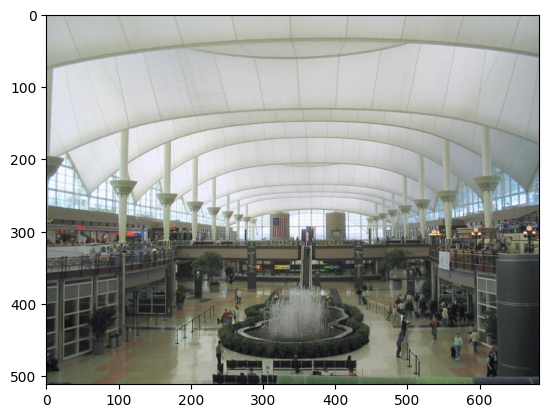

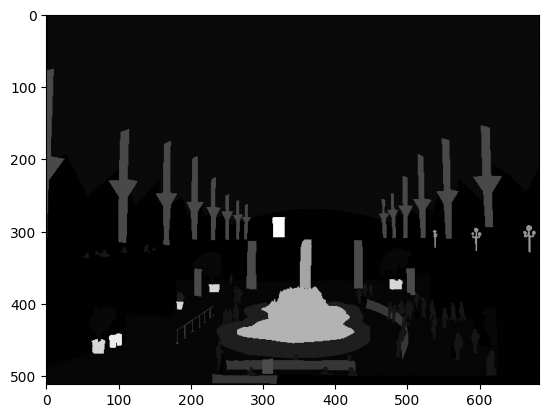

In [ ]:
# Lets visualize some of the files
image_vis = Image.open("CS163/ADE20K/images/training/ADE_train_00000001.jpg")
segmap_vis = Image.open("CS163/ADE20K/annotations/training/ADE_train_00000001.png")

# Visualize the image and shape
plt.figure()
plt.imshow(image_vis)
plt.figure()
plt.imshow(segmap_vis, cmap='gray')

In [ ]:
# Lets take a closer look at the values contained in the segmentation map
print("--- shape ---")
print(np.array(segmap_vis).shape)
print("\n--- contents ---")
print(np.array(segmap_vis))
print("\n--- unique values ---")
print(np.unique(np.array(segmap_vis)))

--- shape ---
(512, 683)

--- contents ---
[[0 0 0 ... 6 6 6]
 [0 0 6 ... 6 6 6]
 [0 0 6 ... 6 6 6]
 ...
 [4 4 4 ... 1 1 0]
 [4 4 4 ... 1 1 0]
 [4 4 4 ... 1 1 1]]

--- unique values ---
[  0   1   4   5   6  13  18  32  33  43  44  88  97 105 126 139 150]


After inspecting the segmenetation map, we observe that it is single channel 2D array, with values ranging from 0 to 150, meaning it has 151 classes in total.

In the ADE20K dataset, the corresponding label colors and names to these values can be found here: https://docs.google.com/spreadsheets/d/1se8YEtb2detS7OuPE86fXGyD269pMycAWe2mtKUj2W8/edit?gid=0#gid=0, which can be visualized as follows:



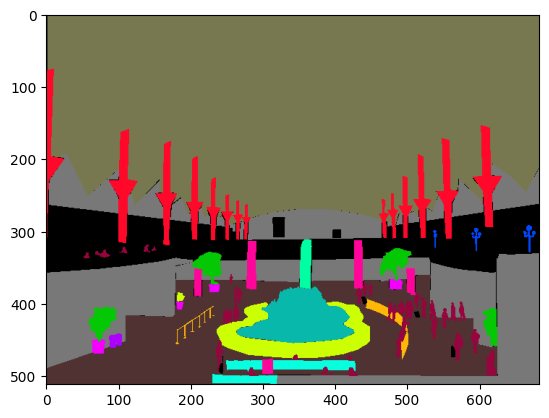

In [ ]:
def visualize_segmap(segmap):
    colors = [(0,0,0), (120,120,120),(180,120,120),(6,230,230),(80,50,50),(4,200,3),(120,120,80),(140,140,140),(204,5,255),(230,230,230),(4,250,7),(224,5,255),(235,255,7),(150,5,61),(120,120,70),(8,255,51),(255,6,82),(143,255,140),(204,255,4),(255,51,7),(204,70,3),(0,102,200),(61,230,250),(255,6,51),(11,102,255),(255,7,71),(255,9,224),(9,7,230),(220,220,220),(255,9,92),(112,9,255),(8,255,214),(7,255,224),(255,184,6),(10,255,71),(255,41,10),(7,255,255),(224,255,8),(102,8,255),(255,61,6),(255,194,7),(255,122,8),(0,255,20),(255,8,41),(255,5,153),(6,51,255),(235,12,255),(160,150,20),(0,163,255),(140,140,140),(250,10,15),(20,255,0),(31,255,0),(255,31,0),(255,224,0),(153,255,0),(0,0,255),(255,71,0),(0,235,255),(0,173,255),(31,0,255),(11,200,200),(255,82,0),(0,255,245),(0,61,255),(0,255,112),(0,255,133),(255,0,0),(255,163,0),(255,102,0),(194,255,0),(0,143,255),(51,255,0),(0,82,255),(0,255,41),(0,255,173),(10,0,255),(173,255,0),(0,255,153),(255,92,0),(255,0,255),(255,0,245),(255,0,102),(255,173,0),(255,0,20),(255,184,184),(0,31,255),(0,255,61),(0,71,255),(255,0,204),(0,255,194),(0,255,82),(0,10,255),(0,112,255),(51,0,255),(0,194,255),(0,122,255),(0,255,163),(255,153,0),(0,255,10),(255,112,0),(143,255,0),(82,0,255),(163,255,0),(255,235,0),(8,184,170),(133,0,255),(0,255,92),(184,0,255),(255,0,31),(0,184,255),(0,214,255),(255,0,112),(92,255,0),(0,224,255),(112,224,255),(70,184,160),(163,0,255),(153,0,255),(71,255,0),(255,0,163),(255,204,0),(255,0,143),(0,255,235),(133,255,0),(255,0,235),(245,0,255),(255,0,122),(255,245,0),(10,190,212),(214,255,0),(0,204,255),(20,0,255),(255,255,0),(0,153,255),(0,41,255),(0,255,204),(41,0,255),(41,255,0),(173,0,255),(0,245,255),(71,0,255),(122,0,255),(0,255,184),(0,92,255),(184,255,0),(0,133,255),(255,214,0),(25,194,194),(102,255,0),(92,0,255)]
    segmap_vis = np.zeros((segmap.shape[0], segmap.shape[1], 3))
    for label in range(0, 150):
        segmap_vis[segmap == label, :] = np.array(colors[label])
    return segmap_vis.astype(np.uint8)


plt.figure()
plt.imshow(visualize_segmap(np.array(segmap_vis)))

#### Q2.1.1 Define the segmentation dataset (5 pt)

In [ ]:

from typing import Any, Callable, Optional, Tuple

class ADE20K(Dataset):
    """`ADE20K Dataset   <https://github.com/CSAILVision/ADE20K>`_.

    Args:
        root (string): Root directory of the dataset.
        split (string, optional): The dataset split, supports ``"training"`` (default) or ``"validation"``.
        transform (callable, optional): A function/transform that takes in a PIL image and returns a transformed
            version. E.g, ``transforms.RandomCrop``.
        target_transform (callable, optional): A function/transform that takes in the target and transforms it.
    """

    def __init__(
        self,
        root: str,
        split: str = "training",
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
    ):
        assert split in ["training", "validation"]

        self.transform = transform
        self.target_transform = target_transform
        self.split = split
        self.root = root

        # Here, you will populate the arrays self.image_paths and self.segmap_paths

        ################# Your Implementations #####################################
        self.image_paths = []
        self.segmap_paths = []

        images_dir = os.path.join(root, 'images', split)
        annotations_dir = os.path.join(root, 'annotations', split)

        image_files = sorted(os.listdir(images_dir))

        for image_file in image_files:
            image_path = os.path.join(images_dir, image_file)
            self.image_paths.append(image_path)

            # replace .jpg with .png for segmentation map filename
            segmap_file = image_file.replace('.jpg', '.png')
            segmap_path = os.path.join(annotations_dir, segmap_file)
            self.segmap_paths.append(segmap_path)

        ################# End of your Implementations ##############################


    def __len__(self) -> int:
        return len(self.image_paths)



    def load_segmentation_map_tensor(self, idx):
        # This function should load the segmentation map as a **Long** Tensor,
        # the expected shape of the loaded segmentation map should be 1 x H x W
        segmap = None
        ################# Your Implementations #####################################


        segmap_pil = Image.open(self.segmap_paths[idx])
        segmap_arr = np.array(segmap_pil)
        segmap = torch.from_numpy(segmap_arr).long()
        segmap = segmap.unsqueeze(0)


        ################# End of your Implementations ##############################

        return segmap

    def __getitem__(self, idx: int) -> Tuple[Any, Any]:
        image = Image.open(self.image_paths[idx]).convert("RGB")
        target = self.load_segmentation_map_tensor(idx)

        if self.transform:
          image = self.transform(image)

        if self.target_transform:
          target = self.target_transform(target)

        return image, target

#### Q2.1.2 Define data transformations (5 pt)


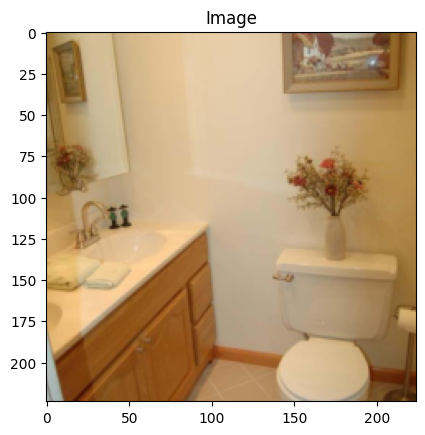

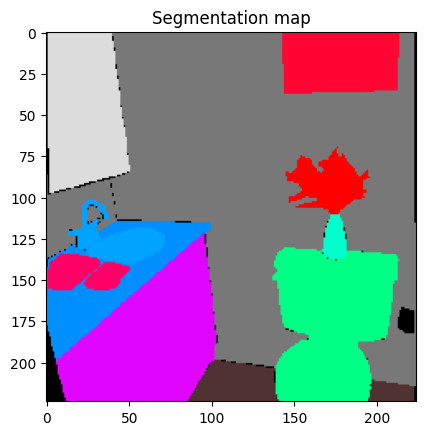

In [ ]:
image_net_mean = torch.Tensor([0.485, 0.456, 0.406])
image_net_std = torch.Tensor([0.229, 0.224, 0.225])

def tensor_to_image(image):
    """
    Convert a tensor image back to a displayable image.

    Args:
        image (torch.Tensor): Tensor image to convert.

    Returns:
        numpy.ndarray: Displayable image.
    """
    tensor_image = image.clone().detach()
    tensor_image = tensor_image.permute(1, 2, 0)
    tensor_image = tensor_image.mul_(image_net_std).add_(image_net_mean)
    numpy_image = tensor_image.numpy()

    return numpy_image

image_transform = None
target_transform = None
normalize = transforms.Normalize(image_net_mean, image_net_std)

# Now, let's define some transformations.
# For the image, you should
# 1.  Resize image such that min(height, width) = 224, while keeping aspect ratio
# 2.  Center crop the resulting image to 3 x 224 x 224
# 3.  Convert to a tensor
# 4.  Normalize using the normalize function defined above

# For the segmentation map, you should
# 1.  Resize image such that min(height, width) = 224, while keeping aspect ratio
# 2.  Center crop the resulting image to 1 x 224 x 224

################# Your Implementations #####################################
# At the end of this function, image_transform and target_transform should be
# updated accordingly.
# Hint: For step 1, transforms.Resize provides a very easy way of doing this
# Hint: Use the NEAREST_EXACT resizing algorithm to make sure values of the
#       segmentation mask are interpolated correctly

image_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize
])

target_transform = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.NEAREST_EXACT),
    transforms.CenterCrop(224)
])

################# End of your Implementations ##############################



train_dataset = ADE20K(root_dir, "training", image_transform, target_transform)
val_dataset = ADE20K(root_dir, "validation", image_transform, target_transform)

# Let's visualize the dataset!
idx = 139
plt.figure()
plt.imshow(tensor_to_image(train_dataset[idx][0]))
plt.title('Image')
plt.figure()
plt.imshow(visualize_segmap(train_dataset[idx][1].permute(1, 2, 0).squeeze(-1).numpy()))
plt.title('Segmentation map')

# If your implementation is correct, all these asserts should pass
assert train_dataset[idx][0].shape == (3, 224, 224)
assert train_dataset[idx][1].shape == (1, 224, 224)
assert np.min(np.unique(train_dataset[idx][1])) >= 0
assert np.max(np.unique(train_dataset[idx][1])) <= 150
assert train_dataset[idx][1].dtype == torch.long

Next, let's define our network. For this exercise, we will be using a pretrained ViT as our image encoder, and a simple customed decoder. The ViT is a small [vit_b_32](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vit_b_32.html#torchvision.models.vit_b_32) model as the backbone so we can train in reasonable time on Colab. This model is similar to the ViT backbone we have implemented above but have much better pretrained weights from ImageNet.


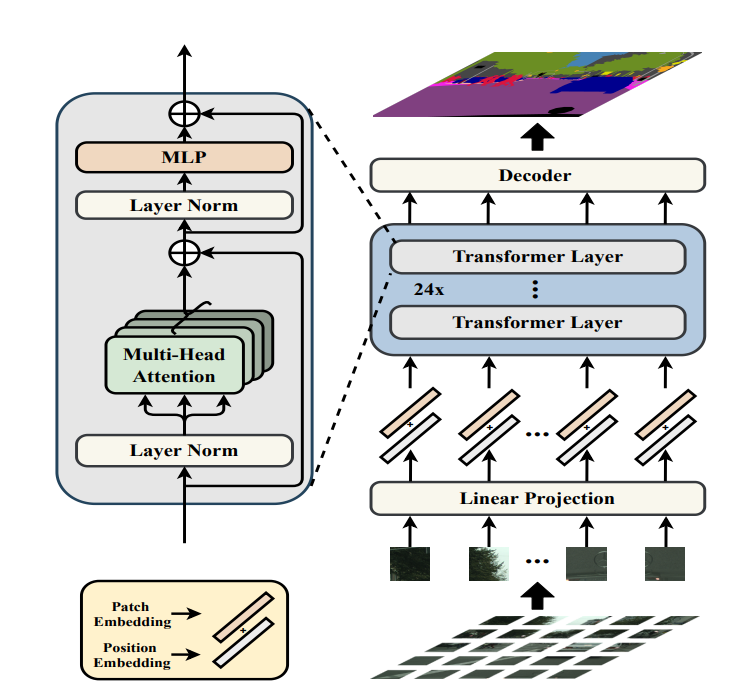

In [ ]:
from torchvision import models
from torchvision.models import feature_extraction

class ImageEncoder(nn.Module):
    """
    ViT network that accepts images as input and outputs global and local features.
    This module serves as the image encoder in image captioning
    model. We will use a tiny vit_b_32 model that is initialized with
    ImageNet-pretrained weights from Torchvision library.
    """

    def __init__(self, pretrained: bool = True, freeze=True, verbose: bool = True):
        """
        Args:
            pretrained: Whether to initialize this model with pretrained weights
                from Torchvision library.
            verbose: Whether to log expected output shapes during instantiation.
        """
        super().__init__()
        self.vit = models.vit_b_32(pretrained=pretrained)
        self.backbone = feature_extraction.create_feature_extractor(
            self.vit, return_nodes={"encoder.ln": "feat"}
        )

        # Torchvision models return global features by default.
        # Our attention-based models may require local patch features. So we
        # wrap the ViT with torchvision's feature extractor.

        # Pass a dummy batch of input images to infer output shape.
        dummy_out = self.backbone(torch.randn(2, 3, 224, 224))["feat"]
        self._out_channels = dummy_out.shape[2]

        if freeze:
            for param in self.vit.parameters():
                param.requires_grad = False

        if verbose:
            print("For input images in NCHW format, shape (2, 3, 224, 224)")
            print(f"Shape of output features: {dummy_out.shape}")

    @property
    def out_channels(self):
        """
        Number of output channels in extracted image features. You may access
        this value freely to define more modules to go with this encoder.
        """
        return self._out_channels

    def forward(self, images: torch.Tensor):
        # Extract features from encoder (backbone) and return.
        # shape: (B, out_channels, H / 32, W / 32)
        features = self.backbone(images)["feat"]
        return features

Note that our ViT encoder will receive input images of shape (224*224) with a patch size of 32 and a feature dimension of 768, returning a feature tensor of shape $(B, (1+7\times7), 768)$.

Our decoder will take in the output of the ViT model before the MLP Head that has shape `(B x (N+1) x dim)`, and output a `(B x 1 x H x W)`
segmentation map. Our decoder will work as follows:

1.  Discard the CLS token, resulting in an output shape `(B x N x dim)`. Note that we do not need the CLS token anymore, since it is used primarily image-level statistics (i.e. class of the image). For semantic segmentation, we instead require a prediction for each individual pixel of the image.
2.  Recall that N = Num. of Patches = `(H / patch_size) * (W / patch_size)`, where `H` and `W` are the height and width of the original image respectively. We will reshape the patches into a 2D image of height `H' = H / patch_size` and width `W' = W / patch_size`. The resulting output shape will be `(B x H' x W' x dim)`.
3.  To be able to perform convolution operations, we will permute the resulting tensor to become `(B x dim x H' x W')`.
4.  We will then pass the resulting output through two convolutional layers. The last layer will output a prediction of shape `(B x num_classes x H' x W')`, where `num_classes` corresponds to the number of classes to predict in the final segmentation map.
5.  Remember `H'` and `W'` are of dimension `(H / patch_size)` and `(W / patch_size)` respectively. Since we want an output segmentation map with the same shape as the original image, we will upsample the map to have shape `(B x num_classes x H x W)`, corresponding to the predicted segmentation map.


### Q2.2 Build the Segmentation Model (15 pt)

#### Q2.2.1 Define the segmentation decoder (10 pt)

In [ ]:
class MySegmentationDecoder(nn.Module):
    def __init__(self,
                 image_size=224,
                 patch_size=32,
                 num_classes=151,
                 dim=768):
        super().__init__()
        """
        Args:
          image_size (int): the height/weight of the input image.
          patch_size (int): image patch size. In our ViT, this value is 32.
          num_classes (num_class): Number of image classes for MLP prediction head.
          dim (int): feature dimension of the ViT model.

        Initialize the semantic segmentation decoder.
        1) Discard CLS token: (B, N+1, dim) -> (B, N, dim)
        2) Reshape output into 2D image with dim channels:
           (B, N, dim) -> (B, dim, H', W') where
            H' := image_size / patch_size
            W' := image_size / patch_size
        3) Define a series of upsample operations such as transposed convolutions or bilinear upsampling, be creative here!
        """

        self.image_size = image_size
        self.patch_size = patch_size
        self.num_classes = num_classes
        self.dim = dim

        ################# Your Implementations #################################

        self.conv1 = nn.Conv2d(dim, 256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU(inplace=True)

        # project to num_classes for final convolution layer
        self.conv3 = nn.Conv2d(128, num_classes, kernel_size=1)

        # upsampling layer is to restore original image size
        self.upsample = nn.Upsample(
            size=(image_size, image_size),
            mode='bilinear',
            align_corners=False
        )

        ################# End of your Implementations ##########################

    def forward(self, x):
        '''
        Forward pass of the segmentation decoder.
        Args:
            x (torch.Tensor): input tensor in the shape of (batch_size,N+1,dim).
        Returns:
            out (torch.Tensor): output tensor in the shape of (batch_size,num_classes,H,W).

        The input tensor 'x' should pass through the following layers:
        1) Discard CLS token
        2) Reshape to (B, dim, H', W')
        3) Apply whatever layers you have defined in __init__ to return out with shape
           (batch_size,num_classes,H,W)
        '''
        out = None

        ################# Your Implementations #################################
        # Hint: you may use
        #     rearrange(x, 'b (h w) d -> b d h w', w=self.image_size // self.patch_size)

        x = x[:, 1:, :]

        out = rearrange(x, 'b (h w) d -> b d h w',
                        h=self.image_size // self.patch_size,
                        w=self.image_size // self.patch_size)

        # (B, dim, H', W') -> (B, 256, H', W')
        out = self.conv1(out)
        out = self.bn1(out)
        out = self.relu1(out)

        # (B, 256, H', W') -> (B, 128, H', W')
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)

        # (B, 128, H', W') -> (B, num_classes, H', W')
        out = self.conv3(out)

        # (B, num_classes, H', W') -> (B, num_classes, H, W)
        out = self.upsample(out)

        ################# End of your Implementations ##########################
        return out

Next, we will define the full ViT Segmentation Model using the ViT encoder and the custom decoder implemented above


#### Q2.2.2 Combine the ViT encoder with the Segmentation Decoder (5 pt)

In [ ]:
class MyVITSegmentationModel(nn.Module):
  def __init__(self,
               image_size=224,
               patch_size=32,
               num_classes=151,
              ):
    super().__init__()
    """
    Args:
      image_size (int): the height/weight of the input image.
      patch_size (int): image patch size. In our ViT, this value is 32.
      num_classes (num_class): Number of image classes for MLP prediction head.

    """

    self.vit_encoder = None
    self.decoder = None

    # Here, you should define
    # 1) self.vit_encoder:  Use the ImageEncoder class defined above with frozen pretrained weights
    #                     The output dimension of this encoder should be used to initialize the decoder
    # 2) self.decoder: Use the parameters in __init__ to initialize MySegmentationDecoder
    ################# Your Implementations #################################

    self.vit_encoder = ImageEncoder(pretrained=True, freeze=True, verbose=False)

    self.decoder = MySegmentationDecoder(
        image_size=image_size, patch_size=patch_size,
        num_classes=num_classes,
        dim=self.vit_encoder.out_channels
    )

    ################# End of your Implementations ##########################

  def forward(self, x):
    '''
    Forward pass of the segmentation model.
    Args:
        img (torch.Tensor): input tensor in the shape of (batch_size,C,H,W).
    Returns:
        out (torch.Tensor): output segmentation map tensor in the shape of (batch_size,C,H,W).

    The input tensor 'x' should pass through the following layers:
    1) ViT Encoder
    2) MySegmentationDecoder
    '''

    out = None

    # Pass the input through the encoder and decoder
    ################# Your Implementations #################################

    encode_feat = self.vit_encoder(x)
    out = self.decoder(encode_feat)

    ################# End of your Implementations ##########################
    return out

### Q2.3 Build the training pipeline (10 pt)



Now, let's define our training and validation script. Our scripts will be mostly the same as before, except we will be using mIoU (mean intersection over union) for our validation criterion.
Recall IoU is defined as
$$\frac{TP}{TP + FP + FN}$$
In other words, given two sets $X, Y$, this gives $$\frac{|X \cap Y|}{|X \cup Y|},$$
and mIOU is simply the average IoU across all classes.

#### Q2.3.1 Defining mIoU (5 pt)

In [ ]:
def mean_iou(logits, target):
  """
  Computes the mean iou score given the predicted and target segmentation map.
  Args:
    logits (torch.Tensor): logits tensor in the shape of (num_classes,H,W)
    target (torch.Tensor): tensor of type Long in the shape of (H,W)
    Returns:
        out (float): single scalar quantity representing the mean iou score
  """

  out = None
  # Recall that the IoU score for each class label is computed as
  # intersection (of positive predictions) over union (of positive predictions)
  # Return the mean iou score over all class labels and batch size
  ################# Your Implementations #################################
  # Hint: First, convert the logits (num_classes, H, W) to class predictions (H, W)
  # Hint: You can use torch.logical_and (or just simply multiplication),
  #       and torch.logical_or for computing intersections and unions
  # Hint: You can use tensor.item() to extract a scalar from a tensor
  # Hint: Skip the class if the size of the union is 0

  predictions = logits.argmax(dim=0)
  num_classes = logits.shape[0]
  iou_scores = []

  for class_id in range(num_classes):
    # pred_mask
    pred_mask = (predictions == class_id)

    # target_mask
    target_mask = (target == class_id)

    intersection = torch.logical_and(pred_mask, target_mask).sum()
    union = torch.logical_or(pred_mask, target_mask).sum()

    # skip class if size of union == 0
    if union.item() == 0:
      continue

    iou = intersection.float() / union.float()
    iou_scores.append(iou.item())

  if len(iou_scores) == 0:
    out = 0.0
  else:
    out = sum(iou_scores) / len(iou_scores)

  ################# End of your Implementations ##########################
  return out

In [ ]:
def train_seg(model, train_loader, val_loader, optimizer, criterion, device, num_epochs):
    """
    Train the segmentation model on the training set and evaluate it on the validation set every epoch.

    Args:
        model (MLP): MLP classifier to train.
        train_loader (torch.utils.data.DataLoader): Data loader for the training set.
        val_loader (torch.utils.data.DataLoader): Data loader for the validation set.
        optimizer (torch.optim.Optimizer): Optimizer to use for training.
        criterion (callable): Loss function to use for training.
        device (torch.device): Device to use for training.
        num_epochs (int): Number of epochs to train the model.
    """
    # Place model on device
    model = model.to(device)

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        # Use tqdm to display a progress bar during training
        with tqdm(total=len(train_loader), desc=f'Epoch {epoch + 1}/{num_epochs}') as pbar:
            for inputs, labels in train_loader:
                # Move inputs and labels to device
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero out gradients
                optimizer.zero_grad()

                # Compute the logits and loss
                logits = model(inputs)

                loss = criterion(logits, labels.squeeze())

                # Backpropagate the loss
                loss.backward()

                # Update the weights
                optimizer.step()

                # Update the progress bar
                pbar.update(1)
                pbar.set_postfix(loss=loss.item())

        # Evaluate the model on the validation set
        avg_loss, avg_iou = evaluate_seg(model, val_loader, criterion, device)
        print(f'Validation set: Average loss = {avg_loss:.4f}, Average IoU = {avg_iou:.4f}')


def evaluate_seg(model, test_loader, criterion, device):
    """
    Evaluate the MLP classifier on the test set.

    Args:
        model (MLP): MLP classifier to evaluate.
        test_loader (torch.utils.data.DataLoader): Data loader for the test set.
        criterion (callable): Loss function to use for evaluation.
        device (torch.device): Device to use for evaluation.

    Returns:
        float: Average loss on the test set.
        float: Accuracy on the test set.
    """
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():
        total_loss = 0.0
        total_iou = 0.0
        num_samples = 0

        for inputs, labels in test_loader:
            # Move inputs and labels to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Compute the logits and loss
            logits = model(inputs)
            loss = criterion(logits, labels.squeeze())
            total_loss += loss.item()

            for logits_b, labels_b in zip(logits, labels):
              # Compute the iou score
              iou = mean_iou(logits_b, labels_b.squeeze(0))
              total_iou += iou

            num_samples += len(inputs)

    # Compute the average loss and accuracy
    avg_loss = total_loss / len(test_loader)
    avg_iou = total_iou / num_samples

    return avg_loss, avg_iou

In [ ]:
seed_everything(0)

# Define the model, optimizer, and criterion (loss_fn)
model = MyVITSegmentationModel(image_size = 224,
    patch_size = 32,
    num_classes = 151,
           )

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,)

criterion = nn.CrossEntropyLoss()

# Define the batch size and number of workers
batch_size = 32
num_workers = 2

# Define the data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

# Train the model
train_seg(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_32_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_32_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth" to /root/.cache/torch/hub/checkpoints/vit_b_32-d86f8d99.pth


100%|██████████| 337M/337M [00:01<00:00, 248MB/s]
Epoch 1/2: 100%|██████████| 632/632 [03:10<00:00,  3.31it/s, loss=1.57]


Validation set: Average loss = 1.4545, Average IoU = 0.2123


Epoch 2/2: 100%|██████████| 632/632 [03:05<00:00,  3.40it/s, loss=1.38]


Validation set: Average loss = 1.3619, Average IoU = 0.2221


If everything goes well, you should be getting a mean validation loss smaller than 1.7 and mIoU greater than 0.15.

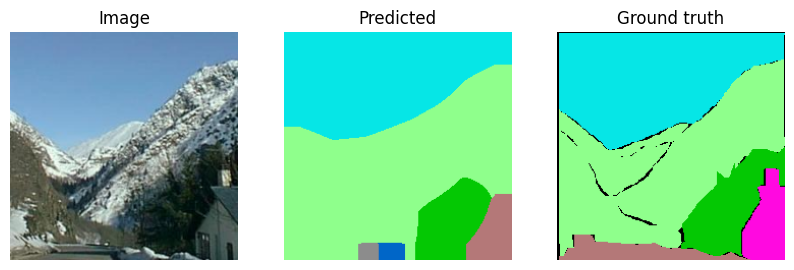

In [ ]:
# Let's visualize what our model has predicted!
 #(You can run this cell multiple times to see how your model performs on different inputs)

idx = np.random.randint(0, len(val_dataset)-1)
img, target = val_dataset[idx]
target_vis = target.float().permute(1,2,0).squeeze(-1).numpy()
with torch.inference_mode():
  img = img.to(device).unsqueeze(0)
  pred = model(img).squeeze(0).argmax(dim=0)
  pred_vis = pred.cpu().float().numpy()

fig, axs = plt.subplots(1,3, figsize=(10,8))
axs[0].axis("off")
axs[0].imshow(tensor_to_image(img[0].cpu()))
axs[0].set_title("Image")
axs[1].axis("off")
axs[1].imshow(visualize_segmap(pred_vis))
axs[2].axis("off")
axs[1].set_title("Predicted")
axs[2].imshow(visualize_segmap(target_vis))
axs[2].set_title("Ground truth")
plt.show()

#### Q2.3.2 Question on validation metrics (5 pt)

In a few sentences, describe what is the difference between IoU and accuracy, and why do we prefer IoU over accuracy for sementic segmentation?




(Double click to edit)

Your Answer:
Accuracy measures percentage of correctly classified pixels over total number of pixels across all classes. IoU measures the overlap between predicted and ground truth regions for each class separately, then averages across classes. For semantic segmentation, we prefer IoU because it penalizes both false positives and false negatives equally and prevents models from achieving high scores just by simply preducting the dominant class for most pixels. For example, the "background" might occupy 80% of pixels while smaller objects like a person or dog are the other 20%. If we have a model that predicted all pixels as the background, accuracy would by 80%, despite the model not being able to detect any of the small objects. IoU on the other hand, measures overlap for each class separately, making it more flexible for class imbalance in an image.

---

## Q3: Segment Anything - A state-of-the-art semantic segmentation model (5 pts)

In this section, we will try out one of the best semantic segmentation models available, and see what it can do!

We will be running [Segment Anything (SAM)](https://segment-anything.com/) by Meta AI. Since it is already pre-trained, we will simply use it for inference. First, let's install it and download the pre-trained Segment Anything model. We will be using the model based on ViT-Huge.

This section will be based off the automatic mask generator class in SegmentAnything, which provides an effective API to generate segmentation masks for an entire image.
This section is inspired by https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

In [ ]:
# Install the segment anything package
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'
# Download the pre-trained weights
os.makedirs(os.path.join('./CS163', 'SegmentAnything', 'weights'), exist_ok=True)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P CS163/SegmentAnything/weights
weights_path = os.path.join('./CS163', 'SegmentAnything', 'weights', "sam_vit_h_4b8939.pth")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



  Preparing metadata (setup.py) ... done


Now that all the setup is done, let's load the model!

In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

# Load the SAM model
sam = sam_model_registry['vit_h'](checkpoint=weights_path).to(device=device)
# Use the automated mask generator class for generating segmentation masks
mask_generator = SamAutomaticMaskGenerator(sam)

Now, let's generate our mask!

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:

- segmentation : the mask
- area : the area of the mask in pixels
- bbox : the boundary box of the mask in XYWH format
- predicted_iou : the model's own prediction for the quality of the mask
- point_coords : the sampled input point that generated this mask
- stability_score : an additional measure of mask quality
- crop_box : the crop of the image used to generate this mask in XYWH format

(as described by https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb)

In [ ]:
image = None
################# Your Implementations #################################
# TODO: Upload your own image and store it as an numpy array
#       You can use an ADE20K image or any image you like
#       An example image can be found here:  https://s3.amazonaws.com/cms.ipressroom.com/173/files/20198/5d72b4772cfac209ff04c634_Royce+Quad/Royce+Quad_hero.jpg

image_path = "CS163/ADE20K/images/validation/ADE_val_00000001.jpg"
image_pil = Image.open(image_path)
image = np.array(image_pil)

################# End of your Implementations ##########################

masks = mask_generator.generate(image)
# masks now contains a list of segmentation masks, stored in the form of a dictionary
print(type(masks))
print(masks[0].keys())

<class 'list'>
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


Let's visualize our segmentations!

In [ ]:
# helper function to visualize masks, taken from https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

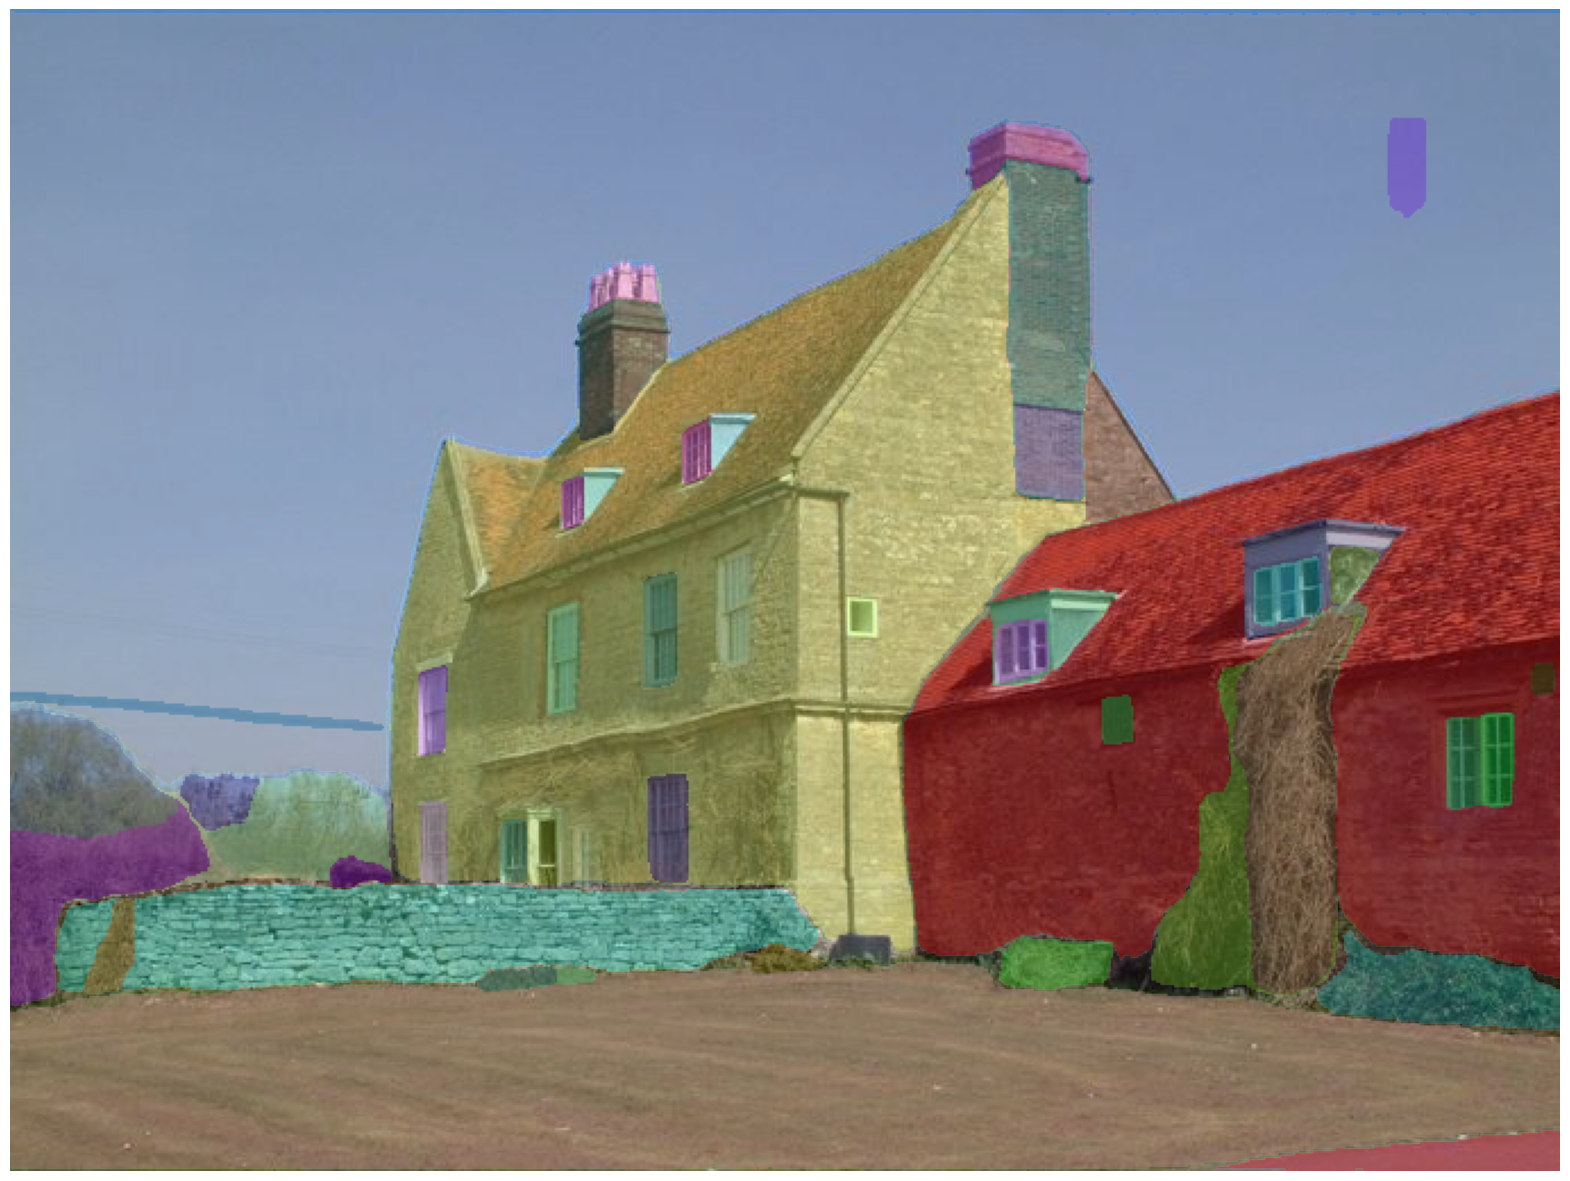

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

Use 2-3 sentences, explain how ViT is used in the segment anything model, and how SAM differs from a traditional segmentation model.

You can refer to the [original paper](https://arxiv.org/abs/2304.02643).


(Double click to edit)

Your Answer:
SAM uses a ViT as its image encoder to process high resolution inputs and capture global and local visual features, resulting in a dense image embedding that represents the entire image. SAM differs from a traditional segmentation model by changing segmentation to be a "classify everything" task to an interactive prompting task. With SAM, you can give it hints/instructions about what you want segmented, ratgher than having the whole image segmented. It can also segment objects in zero-shot fashion, which means that it can segment objects that it hasn't been trained on. There's no need for retraining, you just need to "point" to the new object and it will segment it because it knows what makes something an object in general. With a traditional segmentation model, you would need to retrain the model if you want it to segment a new object.

---

You can play around with this and segment your own images, have fun!